In [ ]:
# ══════════════════════════════════════════════════════════════
# 🔄 RECOVERY CELL — Jalankan HANYA jika sesi Colab restart
# (skip jika masih satu sesi dengan training)
# ══════════════════════════════════════════════════════════════

import os, torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, f1_score, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

# Variabel penting
label2id     = {'negatif': 0, 'positif': 1, 'netral': 2}
id2label     = {0: 'negatif', 1: 'positif', 2: 'netral'}
labels_order = ['negatif', 'netral', 'positif']
SAVE_PATH = '/content/drive/MyDrive/Coolyeah/Skripsi/Analisis_sentimen_youtube'

# Load model dari Drive
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
model.eval()
print('✅ Model berhasil diload dari Drive')

# Load data
train_df      = pd.read_csv(f'{SAVE_PATH}/data_training.csv')
val_df        = pd.read_csv(f'{SAVE_PATH}/data_val.csv')
df_gold       = pd.read_csv('/content/drive/MyDrive/Coolyeah/Skripsi/Analisis_sentimen_youtube/dataset_youtube/data_hasil_labeling_manual.csv', index_col='id')
df_gold_sample = pd.read_csv(f'{SAVE_PATH}/data_gold.csv')

df_gold['label_manual']   = df_gold['label_manual'].str.lower().str.strip()
df_gold['label_otomatis'] = df_gold['label_otomatis'].str.lower().str.strip()

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Gold: {len(df_gold)}')
print('✅ Semua variabel siap — lanjut ke cell evaluasi')

OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/Coolyeah/Skripsi/Analisis_sentimen_youtube'. Use `repo_type` argument if needed.

1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import requests
import io
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, cohen_kappa_score
)
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, pipeline,
    EarlyStoppingCallback
)
from torch import nn
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


2. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Coolyeah/Skripsi/Analisis_sentimen_youtube/dataset_youtube/Dataset_youtube.csv')

df = df[['Comment', 'UserName', 'Date']]

df.head()

,Comment,UserName,Date
0,tidak akan pernah rededominasi keuangan indone...,@ZaenUri-d4e,2026-04-30T06:30:10Z
1,Sok tahu orang baru kemaren.,@MiziMizi-g9j7p,2026-04-27T09:17:38Z
2,Nol di hapus tapi penyebutan atau tulisan huru...,@best.k-s9r,2026-04-16T01:45:58Z
3,"Jgn terlalu takut dan bingung, semuanya insyaA...",@Pakal6627,2026-04-14T11:13:25Z
4,Dulu gagal di Hajar as setelah as Rusia putus ...,@SudarManzyah,2026-04-14T09:57:14Z


3. Dataset Awal

In [ ]:
print("Ukuran dataset: ", df.shape)
print("\nInfo dataset: ", df.info())

print("\n Jumlah missing value: ", df.isnull().sum())

Ukuran dataset:  (3204, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Comment   3204 non-null   object
 1   UserName  3204 non-null   object
 2   Date      3204 non-null   object
dtypes: object(3)
memory usage: 75.2+ KB

Info dataset:  None

 Jumlah missing value:  Comment     0
UserName    0
Date        0
dtype: int64


In [ ]:
all_text = ' '.join(df['Comment'].dropna().astype(str).tolist())

# ── 2. Stopwords Bahasa Indonesia ────────────────────────────────────────────
stopwords_id = set([
    'yang', 'di', 'dan', 'atau', 'ke', 'dari', 'ini', 'itu', 'juga',
    'dengan', 'tidak', 'adalah', 'untuk', 'bisa', 'akan', 'sudah',
    'kami', 'kita', 'ada', 'pada', 'oleh', 'karena', 'jadi', 'tapi',
    'kalau', 'kalo', 'jangan', 'perlu', 'baru', 'lebih', 'sangat',
    'atas', 'dalam', 'setelah', 'saat', 'sama', 'belum', 'harus',
    'baik', 'saja', 'aja', 'mau', 'bagi', 'lagi', 'pun', 'nih', 'sih',
    'yg', 'nya', 'kan', 'nah', 'dong', 'lah', 'oh', 'ya', 'si',
    'ter', 'me', 'kita', 'mereka', 'dia', 'ia', 'saya', 'aku',
    'anda', 'kamu', 'kau', 'itu', 'ini', 'kami', 'kalian',
    'bila', 'bahwa', 'jika', 'maka', 'pun', 'pula', 'namun',
    'tetapi', 'namun', 'namun', 'sedangkan', 'hingga', 'sampai',
    'sejak', 'ketika', 'setelah', 'sebelum', 'sehingga', 'supaya',
    'agar', 'karena', 'sebab', 'meski', 'walau', 'walaupun',
    'meskipun', 'apabila', 'asalkan', 'seiring', 'selain',
    'http', 'https', 'www', 'com', 'co', 'id', 'amp',
    'RT', 'rt', 'yuk', 'dong', 'deh', 'kok', 'lho', 'tuh',
    'gak', 'ga', 'gk', 'nggak', 'enggak', 'udah', 'udh',
    'aja', 'ajah', 'banget', 'bgt', 'emang', 'emg',
])
stopwords_id.update(STOPWORDS)

In [ ]:
wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords_id,
    max_words=150,
    colormap='YlGn',          # kuning → hijau (terang = jarang, gelap = sering)
    collocations=False,       # hindari pasangan kata berulang
    min_font_size=10,
    max_font_size=120,
    prefer_horizontal=0.85,
    random_state=42,
).generate(all_text)

In [ ]:
tokens = [
    w.lower() for w in re.findall(r'\b[a-zA-Z]{3,}\b', all_text)
    if w.lower() not in stopwords_id
]
freq = Counter(tokens).most_common(20)
words_top, counts_top = zip(*freq)


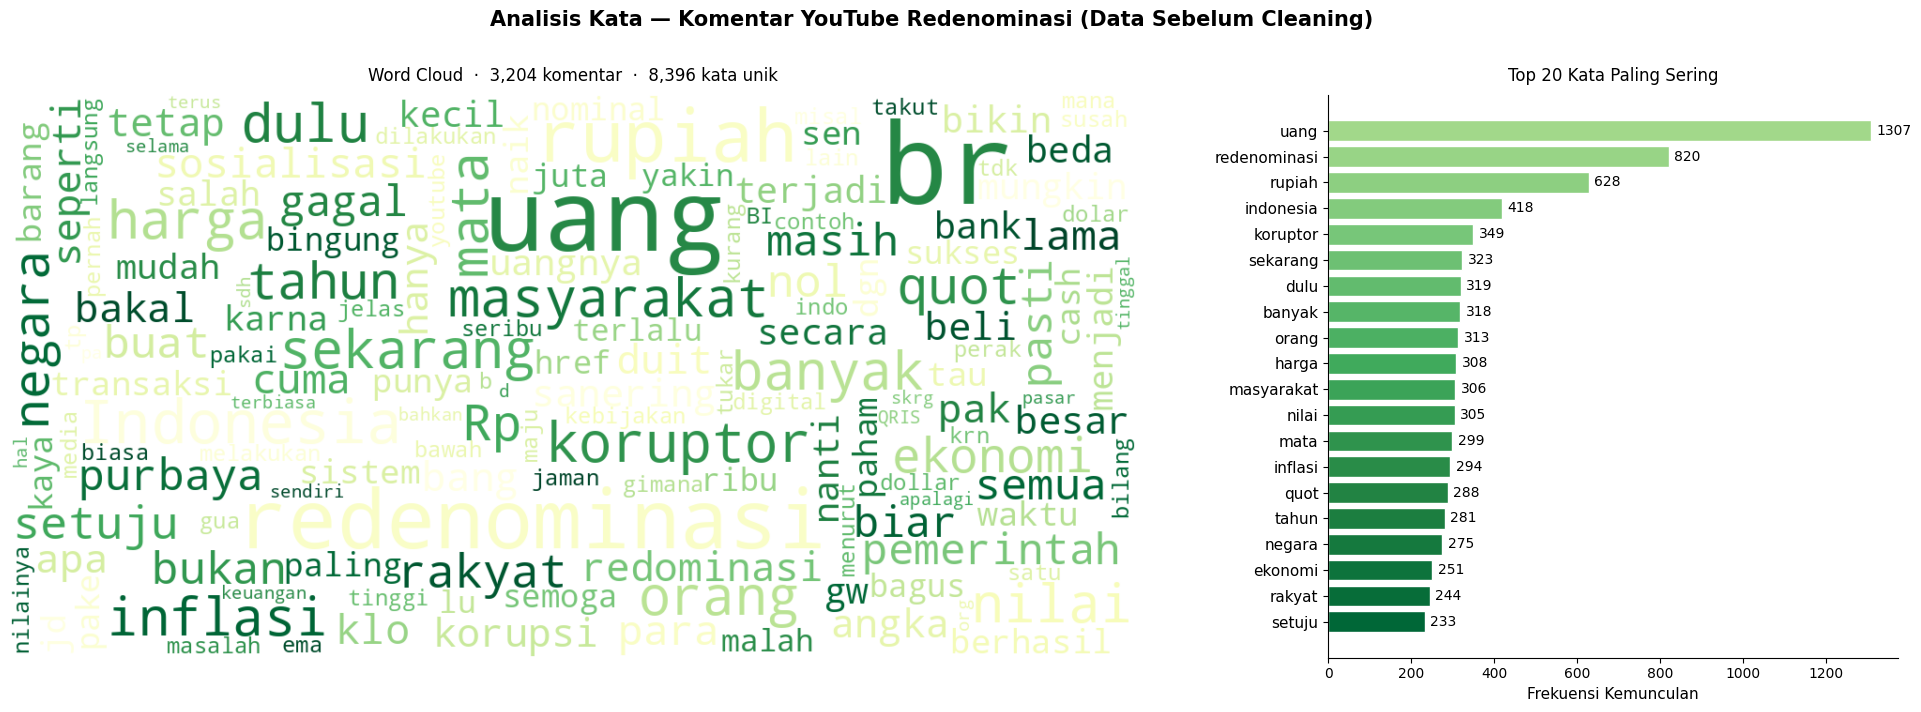


Kata                  Frekuensi
uang                      1,307
redenominasi                820
rupiah                      628
indonesia                   418
koruptor                    349
sekarang                    323
dulu                        319
banyak                      318
orang                       313
harga                       308
masyarakat                  306
nilai                       305
mata                        299
inflasi                     294
quot                        288
tahun                       281
negara                      275
ekonomi                     251
rakyat                      244
setuju                      233

✅ Gambar disimpan: wordcloud_redenominasi_sebelum_cleaning.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7),
                         gridspec_kw={'width_ratios': [2.2, 1]})
fig.suptitle(
    'Analisis Kata — Komentar YouTube Redenominasi (Data Sebelum Cleaning)',
    fontsize=15, fontweight='bold', y=1.01
)

# Panel kiri: WordCloud
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title(
    f'Word Cloud  ·  {len(df):,} komentar  ·  {len(set(tokens)):,} kata unik',
    fontsize=12, pad=10
)

# Panel kanan: Bar chart top-20
colors = plt.cm.YlGn([0.4 + 0.5 * (i / len(counts_top)) for i in range(len(counts_top))])
bars = axes[1].barh(range(len(words_top)), counts_top, color=colors, edgecolor='white')
axes[1].set_yticks(range(len(words_top)))
axes[1].set_yticklabels(words_top, fontsize=11)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frekuensi Kemunculan', fontsize=11)
axes[1].set_title('Top 20 Kata Paling Sering', fontsize=12, pad=10)
axes[1].spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, counts_top):
    axes[1].text(
        bar.get_width() + max(counts_top) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(val), va='center', fontsize=10
    )

plt.tight_layout()
plt.savefig('wordcloud_redenominasi_sebelum_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print(f"{'Kata':<20} {'Frekuensi':>10}")
print(f"{'='*50}")
for w, c in freq:
    print(f"{w:<20} {c:>10,}")
print(f"{'='*50}")
print(f"\n✅ Gambar disimpan: wordcloud_redenominasi_sebelum_cleaning.png")

4. Data Cleaning Dasar

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.0 MB/s eta 0:00:00


In [ ]:
# Hapus data kkosong pada kolom full_text
df = df.dropna(subset=['Comment'])

# Hapus duplikat berdasarkan isi data
df = df.drop_duplicates(subset=['Comment'])

print("Ukuran dataset setelah hapus null dan duplikat: ", df.shape)

Ukuran dataset setelah hapus null dan duplikat:  (3177, 3)


In [ ]:
import re
import emoji

def clean_youtube_text(text):
    text = str(text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)   # hapus mention
    text = re.sub(r'RT[\s]+', '', text)           # hapus RT
    text = re.sub(r'https?://\S+', '', text)      # hapus URL
    text = re.sub(r'#', '', text)                 # hapus simbol #, kata hashtag tetap dipertahankan
    text = emoji.replace_emoji(text, replace='')  # ✅ hapus emoji
    text = re.sub(r'\s+', ' ', text).strip()      # rapikan spasi (tetap di akhir)
    return text

df['clean_text'] = df['Comment'].apply(clean_youtube_text)
df[['Comment', 'clean_text']].head()

,Comment,clean_text
0,tidak akan pernah rededominasi keuangan indone...,tidak akan pernah rededominasi keuangan indone...
1,Sok tahu orang baru kemaren.,Sok tahu orang baru kemaren.
2,Nol di hapus tapi penyebutan atau tulisan huru...,Nol di hapus tapi penyebutan atau tulisan huru...
3,"Jgn terlalu takut dan bingung, semuanya insyaA...","Jgn terlalu takut dan bingung, semuanya insyaA..."
4,Dulu gagal di Hajar as setelah as Rusia putus ...,Dulu gagal di Hajar as setelah as Rusia putus ...


5. Lowercasing

In [ ]:
df['clean_text'] = df['clean_text'].str.lower()
df[['Comment', 'clean_text']].head()

,Comment,clean_text
0,tidak akan pernah rededominasi keuangan indone...,tidak akan pernah rededominasi keuangan indone...
1,Sok tahu orang baru kemaren.,sok tahu orang baru kemaren.
2,Nol di hapus tapi penyebutan atau tulisan huru...,nol di hapus tapi penyebutan atau tulisan huru...
3,"Jgn terlalu takut dan bingung, semuanya insyaA...","jgn terlalu takut dan bingung, semuanya insyaa..."
4,Dulu gagal di Hajar as setelah as Rusia putus ...,dulu gagal di hajar as setelah as rusia putus ...


6. Normalisasi Kata Tidak Baku (Menggunakan kamus nasalsabila/kamus-alay)

In [ ]:
# ── Normalisasi Kata Tidak Baku menggunakan Kamus Alay (nasalsabila) ─────────

import pandas as pd
import requests
import io

# Download kamus slang Indonesia
url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
kamus_df = pd.read_csv(io.StringIO(requests.get(url).text))

# Buat dictionary: {slang: formal}
kamus_dict = dict(zip(kamus_df['slang'], kamus_df['formal']))

print(f"Total kata dalam kamus: {len(kamus_dict)}")
print(f"Contoh entri kamus:")
print(dict(list(kamus_dict.items())[:10]))

Total kata dalam kamus: 4331
Contoh entri kamus:
{'woww': 'wow', 'aminn': 'amin', 'met': 'selamat', 'netaas': 'menetas', 'keberpa': 'keberapa', 'eeeehhhh': 'eh', 'kata2nyaaa': 'kata-katanya', 'hallo': 'halo', 'kaka': 'kakak', 'ka': 'kak'}


In [ ]:
# Fungsi normalisasi
def normalize_text(text):
    words = text.split()
    normalized = [kamus_dict.get(word, word) for word in words]
    return ' '.join(normalized)

# Terapkan ke kolom clean_text
df['clean_text'] = df['clean_text'].apply(normalize_text)

# Verifikasi hasil
df[['Comment', 'clean_text']].head(10)

,Comment,clean_text
0,tidak akan pernah rededominasi keuangan indone...,tidak akan pernah rededominasi keuangan indone...
1,Sok tahu orang baru kemaren.,sok tahu orang baru kemaren.
2,Nol di hapus tapi penyebutan atau tulisan huru...,nol di hapus tapi penyebutan atau tulisan huru...
3,"Jgn terlalu takut dan bingung, semuanya insyaA...","jangan terlalu takut dan bingung, semuanya ins..."
4,Dulu gagal di Hajar as setelah as Rusia putus ...,dulu gagal di hajar as setelah as rusia putus ...
5,rakyat dukung redenominasi .,rakyat dukung redenominasi .
6,1965GAGAL DARI MANA? DARI HONGKONG?... OMONGAN...,1965gagal dari mana? dari hongkong?... omongan...
7,Cara berfikir kita yang salah yang benar 17.00...,cara berpikir kita yang salah yang benar 17.00...
8,Kalo kurang sosialisasi kacau negara ini..,kalo kurang sosialisasi kacau negara ini..
9,Nilai tukar mata uwang kita sudah hancur diam ...,nilai tukar mata uwang kita sudah hancur diam ...


7. Finalisasi Dataset Teks

In [ ]:
data_final = df[['clean_text', 'Date']].copy()
data_final = data_final.rename(columns={'clean_text': 'Comment'})

data_final.head()

,Comment,Date
0,tidak akan pernah rededominasi keuangan indone...,2026-04-30T06:30:10Z
1,sok tahu orang baru kemaren.,2026-04-27T09:17:38Z
2,nol di hapus tapi penyebutan atau tulisan huru...,2026-04-16T01:45:58Z
3,"jangan terlalu takut dan bingung, semuanya ins...",2026-04-14T11:13:25Z
4,dulu gagal di hajar as setelah as rusia putus ...,2026-04-14T09:57:14Z


8. Labeling Menggunakan Model fine-tuning Indobert (Modelbase labeling)

In [ ]:
model_labeler = pipeline(
    'sentiment-analysis',
    model='taufiqdp/indonesian-sentiment',
    tokenizer='taufiqdp/indonesian-sentiment'
)

def predict_label(text):
    result = model_labeler(text[:512])
    return result[0]['label'], result[0]['score']

df[['pred_label', 'confidence']] = df['clean_text'].apply(
    lambda x: pd.Series(predict_label(x))
)

# Normalisasi label ke lowercase
df['pred_label'] = df['pred_label'].str.lower()

print('✅ Pelabelan otomatis selesai')
df[['clean_text', 'pred_label', 'confidence']].head()

config.json:   0%|          | 0.00/922 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

✅ Pelabelan otomatis selesai


,clean_text,pred_label,confidence
0,tidak akan pernah rededominasi keuangan indone...,negatif,0.985387
1,sok tahu orang baru kemaren.,negatif,0.995817
2,nol di hapus tapi penyebutan atau tulisan huru...,negatif,0.976537
3,"jangan terlalu takut dan bingung, semuanya ins...",positif,0.996455
4,dulu gagal di hajar as setelah as rusia putus ...,negatif,0.995626


In [ ]:
# Ambil hanya data dengan confidence > 0.75 (threshold bisa disesuaikan)
low_conf = df[df['confidence'] < 0.75]
high_conf = df[df['confidence'] >= 0.75]

# Filter: hanya gunakan data dengan confidence >= 0.75
df = df[df['confidence'] >= 0.75].reset_index(drop=True)

print(f"Jumlah data setelah filter confidence >= 0.75: {len(df)}")
print(f"\nDistribusi label setelah filter:")
print(df['pred_label'].value_counts())

# # Cek hasil
# print("Data dengan confidence rendah:")
# print(low_conf[['clean_text', 'pred_label', 'confidence']].head())

# print("\nData dengan confidence tinggi:")
# print(high_conf[['clean_text', 'pred_label', 'confidence']].head())

Jumlah data setelah filter confidence >= 0.75: 2724

Distribusi label setelah filter:
pred_label
negatif    1777
positif     554
netral      393
Name: count, dtype: int64


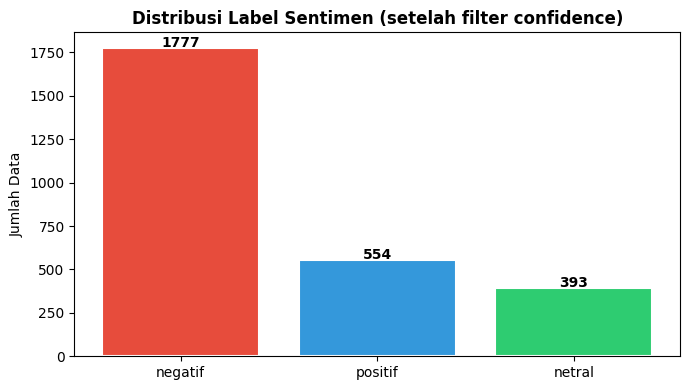

In [ ]:
# Visualisasi distribusi label
label_counts = df['pred_label'].value_counts()
colors = ['#E74C3C', '#3498DB', '#2ECC71']

plt.figure(figsize=(7, 4))
bars = plt.bar(label_counts.index, label_counts.values, color=colors[:len(label_counts)],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold')
plt.title('Distribusi Label Sentimen (setelah filter confidence)', fontweight='bold')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
GOLD_SIZE = 400
RANDOM_STATE = 42

# Stratified sampling — proporsi kelas tetap terjaga
df_gold_sample, df_train_pool = train_test_split(
    df,
    test_size=(len(df) - GOLD_SIZE) / len(df),
    stratify=df['pred_label'],
    random_state=RANDOM_STATE
)

df_gold_sample = df_gold_sample.reset_index(drop=True)
df_train_pool  = df_train_pool.reset_index(drop=True)

print(f'Data gold-standard (untuk labeling manual) : {len(df_gold_sample)}')
print(f'Data training pool (untuk training model)  : {len(df_train_pool)}')
print(f'\nDistribusi label di gold-standard:')
print(df_gold_sample['pred_label'].value_counts())
print(f'\nDistribusi label di training pool:')
print(df_train_pool['pred_label'].value_counts())

Data gold-standard (untuk labeling manual) : 400
Data training pool (untuk training model)  : 2324

Distribusi label di gold-standard:
pred_label
negatif    261
positif     81
netral      58
Name: count, dtype: int64

Distribusi label di training pool:
pred_label
negatif    1516
positif     473
netral      335
Name: count, dtype: int64


In [ ]:
# Export gold-standard untuk labeling manual
df_to_label = df_gold_sample[['clean_text', 'pred_label']].copy()
df_to_label = df_to_label.rename(columns={
    'clean_text' : 'teks',
    'pred_label' : 'label_otomatis'
})
df_to_label['label_manual'] = ''   # kolom ini yang kamu isi
df_to_label['catatan']      = ''   # opsional
df_to_label.index.name = 'id'

df_to_label.to_csv('data_untuk_labeling_manual.csv')

In [ ]:
# Encode label
label2id = {'negatif': 0, 'positif': 1, 'netral': 2}
id2label  = {0: 'negatif', 1: 'positif', 2: 'netral'}

df_train_pool['label'] = df_train_pool['pred_label'].map(label2id)

# Split train / val (90/10) dari training pool
train_df, val_df = train_test_split(
    df_train_pool,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=df_train_pool['label']
)

print(f'Train  : {len(train_df)} data')
print(f'Val    : {len(val_df)} data')
print(f'Gold   : {GOLD_SIZE} data (tidak masuk training)')
print(f'\nDistribusi label training:')
print(train_df['label'].value_counts().map(id2label))

Train  : 2091 data
Val    : 233 data
Gold   : 400 data (tidak masuk training)

Distribusi label training:
label
0    NaN
1    NaN
2    NaN
Name: count, dtype: object


Class Weights: {'negatif': np.float64(0.511), 'positif': np.float64(1.6378), 'netral': np.float64(2.3124)}
Weights tensor: tensor([0.5110, 1.6378, 2.3124])


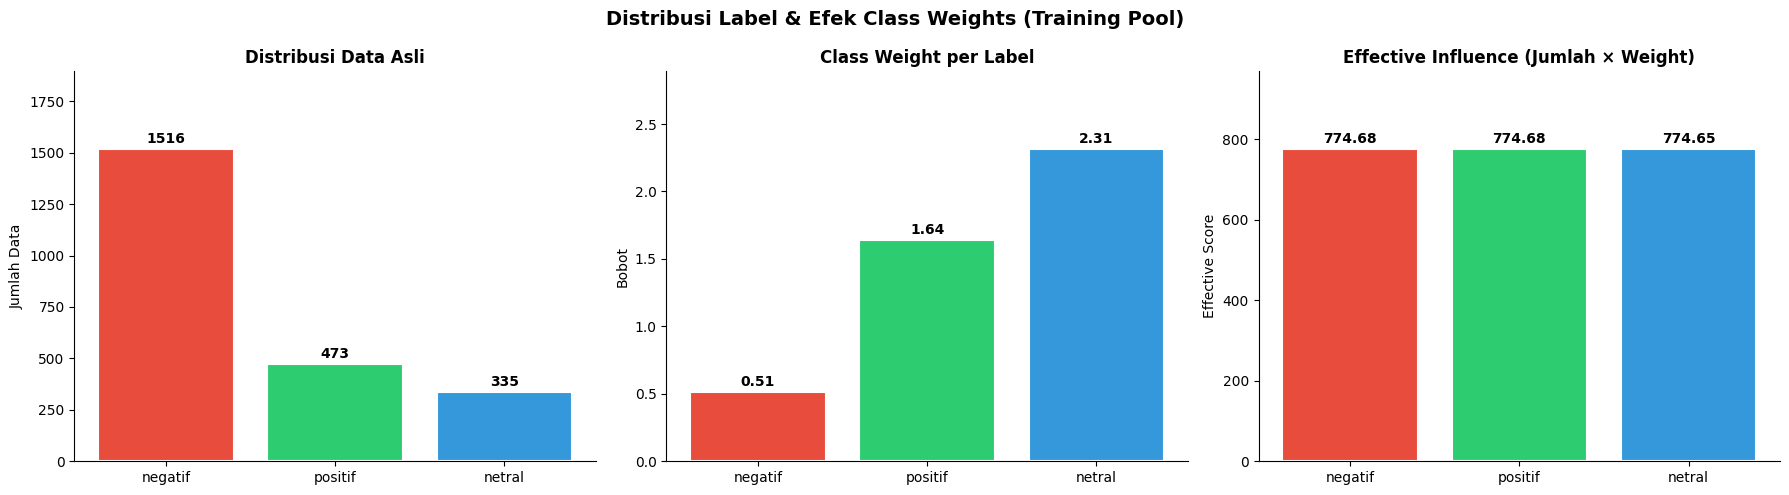

In [ ]:
labels_encoded = df_train_pool['label'].values
class_weights  = compute_class_weight('balanced', classes=np.array([0,1,2]), y=labels_encoded)
weights_tensor = torch.tensor(class_weights, dtype=torch.float)

label_names = ['negatif', 'positif', 'netral']
weight_dict = {label_names[i]: round(class_weights[i], 4) for i in range(3)}
print('Class Weights:', weight_dict)
print('Weights tensor:', weights_tensor)

# Visualisasi
counts   = df_train_pool['pred_label'].value_counts().reindex(label_names)
colors   = ['#E74C3C', '#2ECC71', '#3498DB']
weights  = [weight_dict[l] for l in label_names]
effective = [counts[l] * weight_dict[l] for l in label_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Label & Efek Class Weights (Training Pool)', fontsize=14, fontweight='bold')

for ax, vals, title, ylabel in zip(
    axes,
    [counts.values, weights, effective],
    ['Distribusi Data Asli', 'Class Weight per Label', 'Effective Influence (Jumlah × Weight)'],
    ['Jumlah Data', 'Bobot', 'Effective Score']
):
    bars = ax.bar(label_names, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{v:.2f}' if isinstance(v, float) else str(v),
                ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('class_weights_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
print(f'✅ Model {MODEL_NAME} berhasil diload')

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model indobenchmark/indobert-base-p1 berhasil diload


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch['clean_text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

train_dataset = Dataset.from_pandas(train_df[['clean_text', 'label']].reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df[['clean_text', 'label']].reset_index(drop=True))

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f'✅ Tokenisasi selesai')
print(f'Train dataset: {len(train_dataset)} samples')
print(f'Val dataset  : {len(val_dataset)} samples')

Map:   0%|          | 0/2091 [00:00<?, ? examples/s]

Map:   0%|          | 0/233 [00:00<?, ? examples/s]

✅ Tokenisasi selesai
Train dataset: 2091 samples
Val dataset  : 233 samples


In [ ]:
# Custom Trainer dengan class weight
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get('labels')
        outputs = model(**inputs)
        logits  = outputs.get('logits')
        loss_fn = nn.CrossEntropyLoss(weight=weights_tensor.to(logits.device))
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy'    : accuracy_score(labels, preds),
        'f1_macro'    : f1_score(labels, preds, average='macro'),
        'f1_weighted' : f1_score(labels, preds, average='weighted')
    }

# Training arguments
training_args = TrainingArguments(
    output_dir                  = './indobert-sentiment',
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_dir                 = './logs',
    logging_steps               = 50,
    fp16                        = True,
    seed                        = 42,
)

# Trainer
trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print('✅ Trainer siap — memulai training...')
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Trainer siap — memulai training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.611047,0.344165,0.845494,0.822671,0.851310
2,0.314452,0.292199,0.905579,0.881790,0.907611
3,0.150722,0.375209,0.892704,0.857209,0.891913
4,0.043026,0.436560,0.905579,0.871991,0.904672


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=524, training_loss=0.30774534249123725, metrics={'train_runtime': 23470.7058, 'train_samples_per_second': 0.445, 'train_steps_per_second': 0.028, 'total_flos': 1100340312938496.0, 'train_loss': 0.30774534249123725, 'epoch': 4.0})

In [ ]:
# ══════════════════════════════════════════════════════════════
# 💾 SIMPAN MODEL KE GOOGLE DRIVE (jalankan segera setelah training)
# ══════════════════════════════════════════════════════════════
SAVE_PATH = '/content/drive/MyDrive/Coolyeah/Skripsi/Analisis_sentimen_youtube'

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

# Simpan juga data training & val supaya tidak perlu proses ulang
train_df.to_csv(f'{SAVE_PATH}/data_training.csv', index=False)
val_df.to_csv(f'{SAVE_PATH}/data_val.csv', index=False)
df_gold_sample.to_csv(f'{SAVE_PATH}/data_gold.csv', index=True)

print(f'✅ Model + data tersimpan ke Drive: {SAVE_PATH}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model + data tersimpan ke Drive: /content/drive/MyDrive/Coolyeah/Skripsi/Analisis_sentimen_youtube


In [ ]:
# ── Evaluasi Model di Validation Set (Silver-Standard) ───────────────
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

results_val  = trainer.predict(val_dataset)
preds_val    = np.argmax(results_val.predictions, axis=-1)
true_val     = results_val.label_ids
labels_order = ['negatif', 'netral', 'positif']

print('=' * 60)
print('EVALUASI MODEL DI VALIDATION SET (Silver-Standard)')
print('=' * 60)
print(classification_report(
    true_val, preds_val,
    target_names=labels_order
))

EVALUASI MODEL DI VALIDATION SET (Silver-Standard)
              precision    recall  f1-score   support

     negatif       0.97      0.90      0.94       152
      netral       0.87      0.85      0.86        47
     positif       0.74      1.00      0.85        34

    accuracy                           0.91       233
   macro avg       0.86      0.92      0.88       233
weighted avg       0.92      0.91      0.91       233



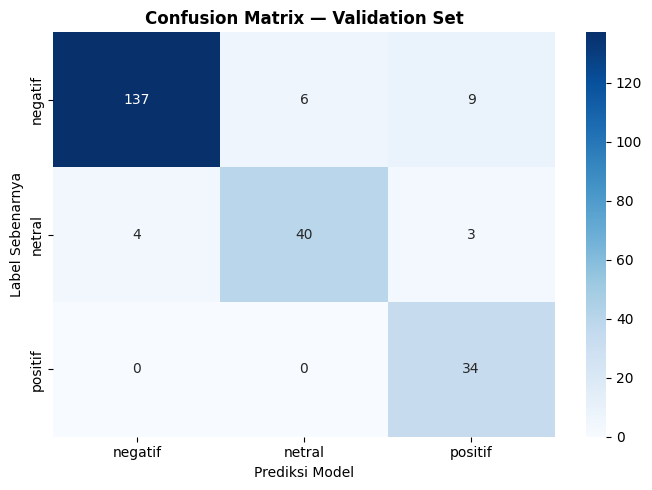

In [ ]:
# Confusion matrix val set
cm_val = confusion_matrix(true_val, preds_val)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order,
            yticklabels=labels_order)
plt.title('Confusion Matrix — Validation Set', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.tight_layout()
plt.savefig('confusion_matrix_val.png', dpi=150, bbox_inches='tight')
plt.show()

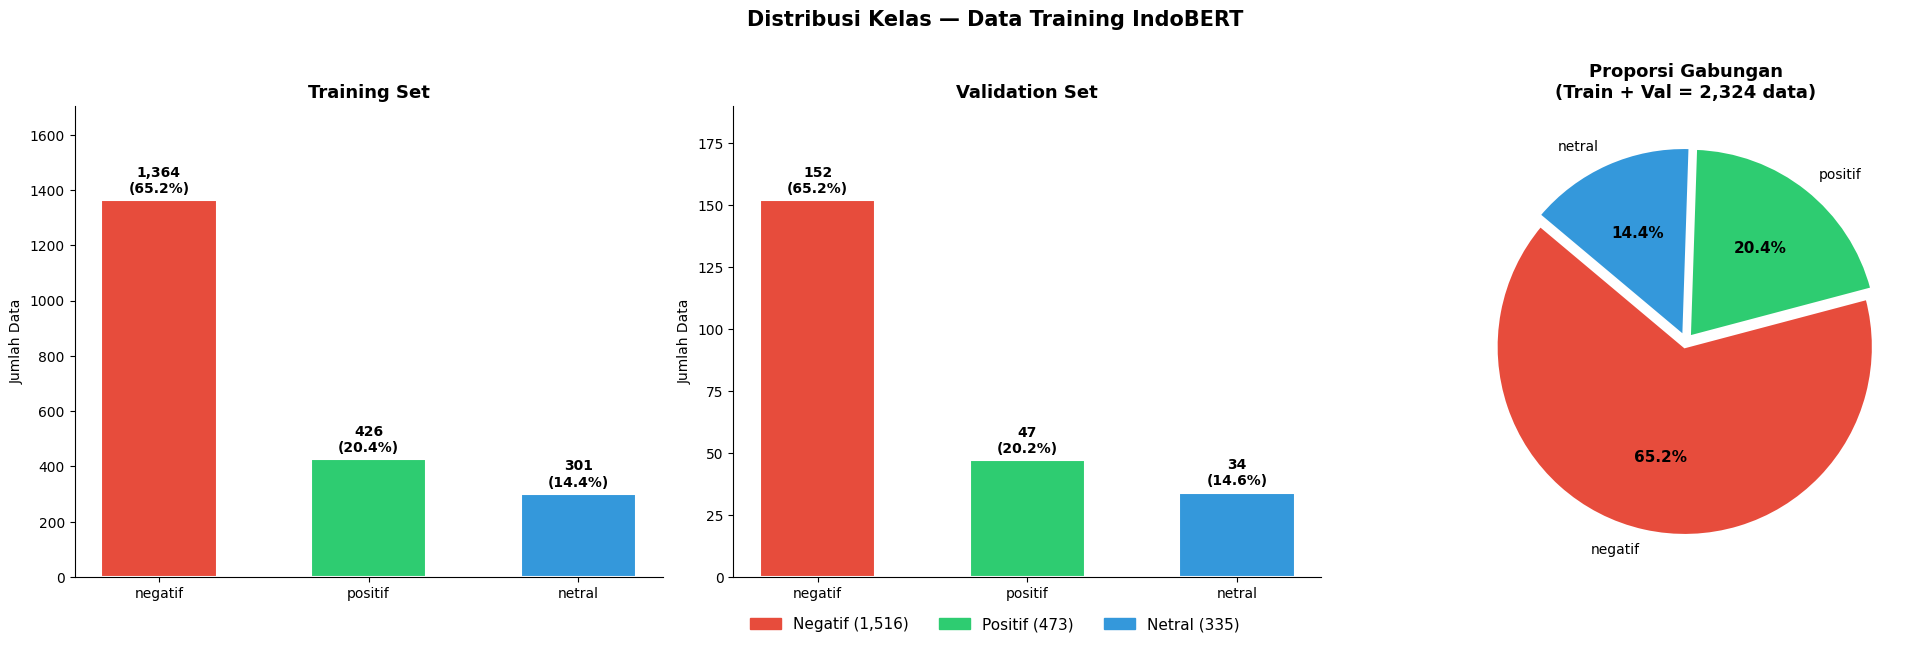


Kelas           Train      Val    Total       %
negatif         1,364      152    1,516   65.2%
positif           426       47      473   20.4%
netral            301       34      335   14.4%
TOTAL           2,091      233    2,324  100.0%


In [ ]:
# ══════════════════════════════════════════════════════════════
# 📊 DISTRIBUSI KELAS HASIL TRAINING DATA
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

label_names  = ['negatif', 'positif', 'netral']
colors_map   = {'negatif': '#E74C3C', 'positif': '#2ECC71', 'netral': '#3498DB'}

# Hitung distribusi dari train_df
train_counts = train_df['pred_label'].value_counts().reindex(label_names)
val_counts   = val_df['pred_label'].value_counts().reindex(label_names)
total        = train_counts.sum() + val_counts.sum()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Distribusi Kelas — Data Training IndoBERT', fontsize=15, fontweight='bold', y=1.01)

# ── Panel 1: Bar chart training set ──────────────────────────
colors = [colors_map[l] for l in label_names]
bars   = axes[0].bar(label_names, train_counts.values, color=colors,
                     edgecolor='white', linewidth=1.5, width=0.55)
axes[0].set_title('Training Set', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, train_counts.max() * 1.25)
axes[0].spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, train_counts.values):
    pct = val / train_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + train_counts.max() * 0.02,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# ── Panel 2: Bar chart val set ────────────────────────────────
bars2 = axes[1].bar(label_names, val_counts.values, color=colors,
                    edgecolor='white', linewidth=1.5, width=0.55)
axes[1].set_title('Validation Set', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Data')
axes[1].set_ylim(0, val_counts.max() * 1.25)
axes[1].spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars2, val_counts.values):
    pct = val / val_counts.sum() * 100
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + val_counts.max() * 0.02,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# ── Panel 3: Pie chart gabungan train+val ────────────────────
combined = train_counts + val_counts
explode  = [0.03] * 3
wedges, texts, autotexts = axes[2].pie(
    combined.values,
    labels=label_names,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[2].set_title(f'Proporsi Gabungan\n(Train + Val = {total:,} data)',
                  fontsize=13, fontweight='bold')

# Legend
patches = [mpatches.Patch(color=colors_map[l], label=f'{l.capitalize()} ({combined[l]:,})') for l in label_names]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11,
           frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('distribusi_kelas_training.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*45}")
print(f"{'Kelas':<12} {'Train':>8} {'Val':>8} {'Total':>8} {'%':>7}")
print(f"{'='*45}")
for l in label_names:
    tot = train_counts[l] + val_counts[l]
    print(f"{l:<12} {train_counts[l]:>8,} {val_counts[l]:>8,} {tot:>8,} {tot/total*100:>6.1f}%")
print(f"{'='*45}")
print(f"{'TOTAL':<12} {train_counts.sum():>8,} {val_counts.sum():>8,} {total:>8,} {'100.0%':>7}")


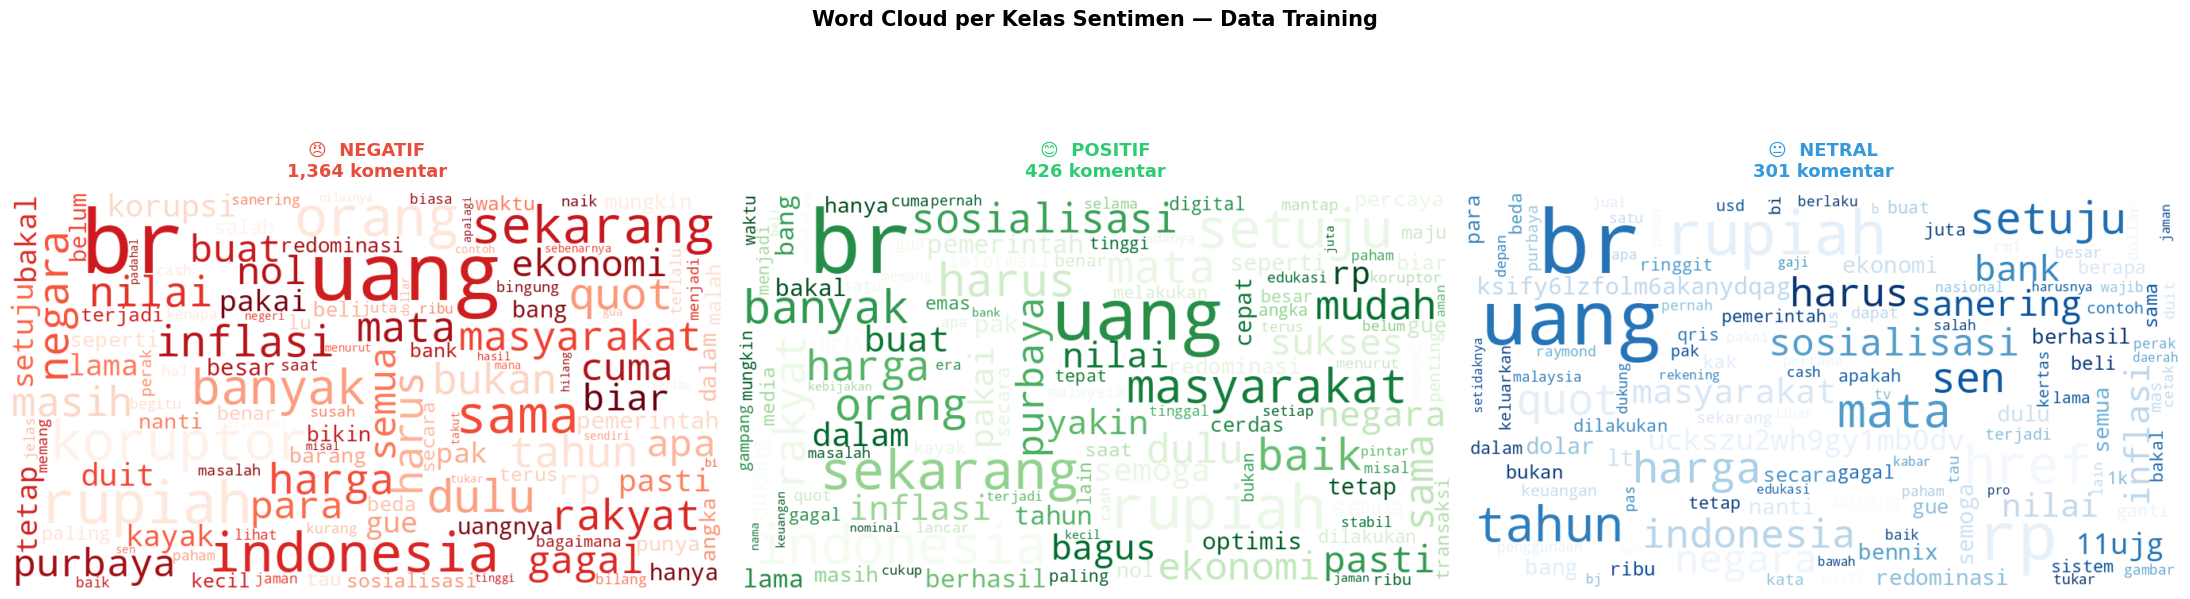

✅ WordCloud per kelas tersimpan: wordcloud_per_kelas.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# ☁️  WORDCLOUD PER KELAS SENTIMEN (dari data training)
# ══════════════════════════════════════════════════════════════
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Stopwords
stopwords_id = set([
    'yang', 'di', 'dan', 'atau', 'ke', 'dari', 'ini', 'itu', 'juga',
    'dengan', 'tidak', 'adalah', 'untuk', 'bisa', 'akan', 'sudah',
    'kami', 'kita', 'ada', 'pada', 'oleh', 'karena', 'jadi', 'tapi',
    'kalau', 'kalo', 'jangan', 'perlu', 'baru', 'lebih', 'sangat',
    'saja', 'aja', 'mau', 'bagi', 'lagi', 'pun', 'nih', 'sih',
    'yg', 'nya', 'kan', 'nah', 'dong', 'lah', 'oh', 'ya', 'si',
    'saya', 'aku', 'anda', 'kamu', 'mereka', 'dia',
    'bila', 'bahwa', 'jika', 'maka', 'pula', 'namun',
    'tetapi', 'sedangkan', 'hingga', 'sampai', 'sejak', 'ketika',
    'setelah', 'sebelum', 'sehingga', 'supaya', 'agar', 'sebab',
    'meski', 'walau', 'walaupun', 'meskipun', 'apabila', 'asalkan',
    'http', 'https', 'www', 'com', 'co', 'id', 'amp',
    'rt', 'yuk', 'deh', 'kok', 'lho', 'tuh',
    'gak', 'ga', 'gk', 'nggak', 'enggak', 'udah', 'udh',
    'ajah', 'banget', 'bgt', 'emang', 'emg', 'redenominasi',
])
stopwords_id.update(STOPWORDS)

# Config per kelas
kelas_config = {
    'negatif': {'colormap': 'Reds',    'color': '#E74C3C', 'emoji': '😠'},
    'positif': {'colormap': 'Greens',  'color': '#2ECC71', 'emoji': '😊'},
    'netral':  {'colormap': 'Blues',   'color': '#3498DB', 'emoji': '😐'},
}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Word Cloud per Kelas Sentimen — Data Training',
             fontsize=15, fontweight='bold', y=1.02)

for ax, (kelas, cfg) in zip(axes, kelas_config.items()):
    # Ambil teks dari training pool sesuai kelas
    subset = train_df[train_df['pred_label'] == kelas]['clean_text']
    teks   = ' '.join(subset.dropna().astype(str).tolist())

    if not teks.strip():
        ax.text(0.5, 0.5, f'Tidak ada data\n{kelas}',
                ha='center', va='center', transform=ax.transAxes, fontsize=13)
        ax.axis('off')
        continue

    wc = WordCloud(
        width=900, height=500,
        background_color='white',
        stopwords=stopwords_id,
        max_words=120,
        colormap=cfg['colormap'],
        collocations=False,
        min_font_size=10,
        max_font_size=110,
        prefer_horizontal=0.85,
        random_state=42,
    ).generate(teks)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(
        f"{cfg['emoji']}  {kelas.upper()}\n{len(subset):,} komentar",
        fontsize=13, fontweight='bold', color=cfg['color'], pad=12
    )

    # Border berwarna per kelas
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(cfg['color'])
        spine.set_linewidth(2.5)

plt.tight_layout()
plt.savefig('wordcloud_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ WordCloud per kelas tersimpan: wordcloud_per_kelas.png')

In [ ]:
# Import hasil labeling manual
df_gold = pd.read_csv('/content/drive/MyDrive/Coolyeah/Skripsi/Analisis_sentimen_youtube/dataset_youtube/data_hasil_labeling_manual.csv', index_col='id')

# Hapus baris yang belum dilabeli
df_gold = df_gold[df_gold['label_manual'].notna()]
df_gold = df_gold[df_gold['label_manual'] != '']

# Normalisasi format label
df_gold['label_manual']   = df_gold['label_manual'].str.lower().str.strip()
df_gold['label_otomatis'] = df_gold['label_otomatis'].str.lower().str.strip()

print(f'✅ Jumlah data gold-standard: {len(df_gold)}')
print(f'\nDistribusi label manual:')
print(df_gold['label_manual'].value_counts())

✅ Jumlah data gold-standard: 400

Distribusi label manual:
label_manual
negatif    180
positif    138
netral      82
Name: count, dtype: int64


In [ ]:
y_manual   = df_gold['label_manual']
y_otomatis = df_gold['label_otomatis']

agreement = (y_manual == y_otomatis).mean()
kappa     = cohen_kappa_score(y_manual, y_otomatis)

print(f'Tingkat kesesuaian label otomatis vs manual: {agreement:.2%}')
print(f"Cohen's Kappa: {kappa:.3f}")

if kappa >= 0.8:
    print('Interpretasi: Almost perfect agreement ✅')
elif kappa >= 0.6:
    print('Interpretasi: Substantial agreement — kualitas label otomatis baik ✅')
elif kappa >= 0.4:
    print('Interpretasi: Moderate agreement — perlu diakui sebagai limitasi ⚠️')
else:
    print('Interpretasi: Fair/poor agreement ❌')

print()
print('Detail per kelas (label otomatis dinilai terhadap label manual):')
print(classification_report(y_manual, y_otomatis,
                            target_names=['negatif', 'netral', 'positif']))

Tingkat kesesuaian label otomatis vs manual: 67.00%
Cohen's Kappa: 0.456
Interpretasi: Moderate agreement — perlu diakui sebagai limitasi ⚠️

Detail per kelas (label otomatis dinilai terhadap label manual):
              precision    recall  f1-score   support

     negatif       0.63      0.92      0.75       180
      netral       0.72      0.51      0.60        82
     positif       0.75      0.44      0.56       138

    accuracy                           0.67       400
   macro avg       0.70      0.62      0.64       400
weighted avg       0.69      0.67      0.65       400



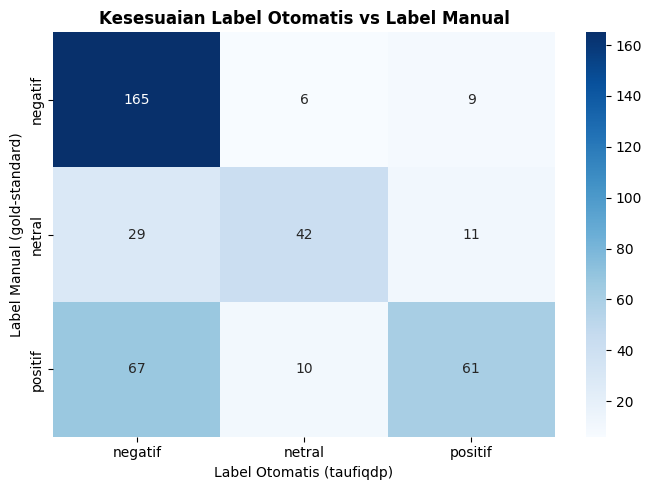

In [ ]:
# Confusion matrix kesesuaian label
labels_order = ['negatif', 'netral', 'positif']
cm_label = confusion_matrix(y_manual, y_otomatis, labels=labels_order)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_label, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title('Kesesuaian Label Otomatis vs Label Manual', fontweight='bold')
plt.xlabel('Label Otomatis (taufiqdp)')
plt.ylabel('Label Manual (gold-standard)')
plt.tight_layout()
plt.savefig('kesesuaian_label.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Prediksi model di 400 data gold-standard
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

# ── Bersihkan kolom teks sebelum prediksi ────────────────────────────
df_gold['teks'] = df_gold['teks'].fillna('').astype(str).str.strip()

# Hapus baris yang teksnya kosong setelah dibersihkan
df_gold = df_gold[df_gold['teks'] != ''].reset_index(drop=True)
print(f'Jumlah data gold setelah bersihkan: {len(df_gold)}')

def predict_batch(texts, batch_size=32):
    all_preds = []
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i+batch_size]
        batch  = [str(t).strip() if t else 'kosong' for t in batch]
        inputs = tokenizer(
            batch, return_tensors='pt',
            padding=True, truncation=True, max_length=256
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}  # ← pindah ke sini, di luar tokenizer()
        with torch.no_grad():
            outputs = model(**inputs)
        preds = outputs.logits.argmax(dim=1).tolist()
        all_preds.extend([id2label[p] for p in preds])
        print(f'  Progress: {min(i+batch_size, len(texts))}/{len(texts)}')
    return all_preds

print('Memulai prediksi pada gold-standard test set...')
y_pred_gold = predict_batch(df_gold['teks'].tolist())
df_gold['label_prediksi'] = y_pred_gold
print('✅ Prediksi selesai')

Jumlah data gold setelah bersihkan: 398
Memulai prediksi pada gold-standard test set...
  Progress: 32/398
  Progress: 64/398
  Progress: 96/398
  Progress: 128/398
  Progress: 160/398
  Progress: 192/398
  Progress: 224/398
  Progress: 256/398
  Progress: 288/398
  Progress: 320/398
  Progress: 352/398
  Progress: 384/398
  Progress: 398/398
✅ Prediksi selesai


In [ ]:
y_gold_true   = df_gold['label_manual']
y_silver_true = df_gold['label_otomatis']
y_pred        = df_gold['label_prediksi']

print('=' * 60)
print('EVALUASI MODEL DI GOLD-STANDARD TEST SET (label manual)')
print('=' * 60)
print(classification_report(y_gold_true, y_pred,
                            target_names=labels_order))

print('=' * 60)
print('EVALUASI MODEL DI SILVER-STANDARD TEST SET (label otomatis)')
print('=' * 60)
print(classification_report(y_silver_true, y_pred,
                            target_names=labels_order))

EVALUASI MODEL DI GOLD-STANDARD TEST SET (label manual)
              precision    recall  f1-score   support

     negatif       0.65      0.87      0.74       180
      netral       0.59      0.54      0.56        80
     positif       0.75      0.46      0.57       138

    accuracy                           0.66       398
   macro avg       0.66      0.62      0.62       398
weighted avg       0.67      0.66      0.64       398

EVALUASI MODEL DI SILVER-STANDARD TEST SET (label otomatis)
              precision    recall  f1-score   support

     negatif       0.93      0.85      0.89       261
      netral       0.67      0.84      0.75        58
     positif       0.74      0.78      0.76        79

    accuracy                           0.84       398
   macro avg       0.78      0.83      0.80       398
weighted avg       0.85      0.84      0.84       398



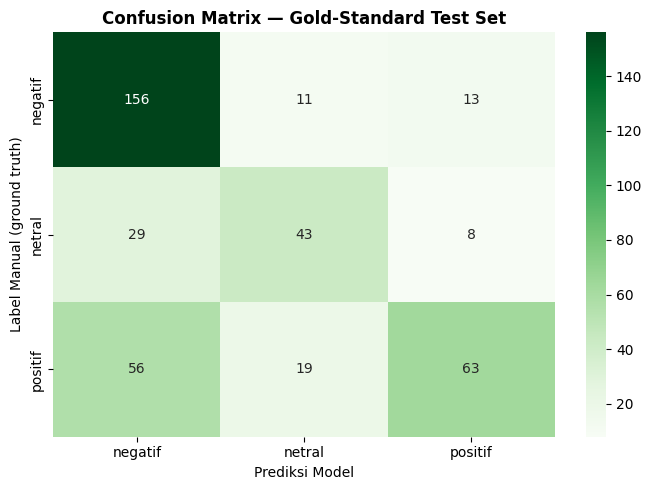

In [ ]:
# Confusion matrix gold-standard
cm_gold = confusion_matrix(y_gold_true, y_pred, labels=labels_order)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_gold, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title('Confusion Matrix — Gold-Standard Test Set', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Manual (ground truth)')
plt.tight_layout()
plt.savefig('confusion_matrix_gold.png', dpi=150, bbox_inches='tight')
plt.show()

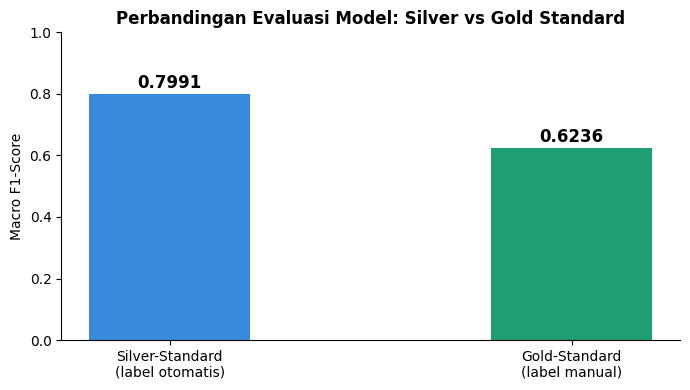

In [ ]:
# Grafik perbandingan Macro F1
f1_gold   = f1_score(y_gold_true, y_pred, average='macro')
f1_silver = f1_score(y_silver_true, y_pred, average='macro')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Silver-Standard\n(label otomatis)', 'Gold-Standard\n(label manual)'],
    [f1_silver, f1_gold],
    color=['#378ADD', '#1D9E75'],
    width=0.4
)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Macro F1-Score')
ax.set_title('Perbandingan Evaluasi Model: Silver vs Gold Standard', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, [f1_silver, f1_gold]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('perbandingan_silver_gold.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Simpan hasil evaluasi lengkap
df_gold.to_csv('hasil_evaluasi_gold_standard.csv', index=True)

print('=' * 60)
print('RINGKASAN HASIL UNTUK SKRIPSI')
print('=' * 60)
print(f'Jumlah data gold-standard                  : {len(df_gold)}')
print(f'Tingkat kesesuaian label otomatis vs manual: {agreement:.2%}')
print(f"Cohen's Kappa (otomatis vs manual)         : {kappa:.4f}")
print(f'Macro F1 model di silver-standard          : {f1_silver:.4f}')
print(f'Macro F1 model di gold-standard            : {f1_gold:.4f}')
print()
print('File yang tersimpan:')
print('  distribusi_label.png            — distribusi label sentimen')
print('  class_weights_visualization.png — visualisasi class weight')
print('  kesesuaian_label.png            — confusion matrix kesesuaian label')
print('  confusion_matrix_gold.png       — confusion matrix gold-standard')
print('  perbandingan_silver_gold.png    — grafik perbandingan evaluasi')
print('  hasil_evaluasi_gold_standard.csv — data lengkap hasil evaluasi')

RINGKASAN HASIL UNTUK SKRIPSI
Jumlah data gold-standard                  : 398
Tingkat kesesuaian label otomatis vs manual: 67.00%
Cohen's Kappa (otomatis vs manual)         : 0.4562
Macro F1 model di silver-standard          : 0.7991
Macro F1 model di gold-standard            : 0.6236

File yang tersimpan:
  distribusi_label.png            — distribusi label sentimen
  class_weights_visualization.png — visualisasi class weight
  kesesuaian_label.png            — confusion matrix kesesuaian label
  confusion_matrix_gold.png       — confusion matrix gold-standard
  perbandingan_silver_gold.png    — grafik perbandingan evaluasi
  hasil_evaluasi_gold_standard.csv — data lengkap hasil evaluasi


In [ ]:
# ══════════════════════════════════════════════════════════════
# 💾 BACKUP HASIL EVALUASI KE DRIVE
# ══════════════════════════════════════════════════════════════
import shutil, os

DRIVE_RESULT = '/content/drive/MyDrive/Coolyeah/Skripsi/analisis_sentimen_youtube/hasil_evaluasi'
os.makedirs(DRIVE_RESULT, exist_ok=True)

# Pindahkan semua output penting ke Drive
for fname in [
    'hasil_evaluasi_gold_standard.csv',
    'confusion_matrix_gold.png',
    'confusion_matrix_val.png',
    'perbandingan_silver_gold.png',
    'kesesuaian_label.png',
    'class_weights_visualization.png',
    'distribusi_label.png',
    'distribusi_kelas_training.png',
    'wordcloud_per_kelas.png',
]:
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{DRIVE_RESULT}/{fname}')
        print(f'✅ {fname} → Drive')
    else:
        print(f'⚠️  {fname} tidak ditemukan (mungkin belum dijalankan)')

print('\n✅ Semua hasil sudah aman di Drive!')

✅ hasil_evaluasi_gold_standard.csv → Drive
✅ confusion_matrix_gold.png → Drive
✅ confusion_matrix_val.png → Drive
✅ perbandingan_silver_gold.png → Drive
✅ kesesuaian_label.png → Drive
✅ class_weights_visualization.png → Drive
✅ distribusi_label.png → Drive
✅ distribusi_kelas_training.png → Drive
✅ wordcloud_per_kelas.png → Drive

✅ Semua hasil sudah aman di Drive!
